In [15]:
import h5py
import time
import torch
import matplotlib.pyplot as plt
import math
import cv2
import numpy as np

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [16]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [18]:
def h5_to_tensor(h5_file_path):
    dataset_tensor = {}

    with h5py.File(h5_file_path, 'r') as h5:
        keys = list(h5.keys())

        for key in keys:
            data = h5[key][:]
            dataset_tensor[key] = torch.from_numpy(data)

    return dataset_tensor

In [19]:
training_data = h5_to_tensor("data/Signs_Data_Training.h5")

print(training_data.keys())

dict_keys(['list_classes', 'train_set_x', 'train_set_y'])


In [20]:
training_data

{'list_classes': tensor([0, 1, 2, 3, 4, 5]),
 'train_set_x': tensor([[[[227, 220, 214],
           [227, 221, 215],
           [227, 222, 215],
           ...,
           [232, 230, 224],
           [231, 229, 222],
           [230, 229, 221]],
 
          [[227, 221, 214],
           [227, 221, 215],
           [228, 221, 215],
           ...,
           [232, 230, 224],
           [231, 229, 222],
           [231, 229, 221]],
 
          [[227, 221, 214],
           [227, 221, 214],
           [227, 221, 215],
           ...,
           [232, 230, 224],
           [231, 229, 223],
           [230, 229, 221]],
 
          ...,
 
          [[119,  81,  51],
           [124,  85,  55],
           [127,  87,  58],
           ...,
           [210, 211, 211],
           [211, 212, 210],
           [210, 211, 210]],
 
          [[119,  79,  51],
           [124,  84,  55],
           [126,  85,  56],
           ...,
           [210, 211, 210],
           [210, 211, 210],
           [209, 21

In [21]:
X_train = training_data["train_set_x"].to(device)
y_train = training_data["train_set_y"].to(device)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: torch.Size([1080, 64, 64, 3])
y_train shape: torch.Size([1080])


# Test Data

In [22]:
testing_data = h5_to_tensor("data/Signs_Data_Testing.h5")

print(testing_data.keys())

dict_keys(['list_classes', 'test_set_x', 'test_set_y'])


In [23]:
X_test = testing_data["test_set_x"].to(device)
y_test = testing_data["test_set_y"].to(device)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: torch.Size([120, 64, 64, 3])
y_test shape: torch.Size([120])


# Data Preprocessing

### Checking NUll Vaue

In [24]:
print(X_train.isnan().sum())
print(y_train.isnan().sum())

tensor(0)
tensor(0)


In [25]:
y_train.unique()

tensor([0, 1, 2, 3, 4, 5])

In [26]:
# Display images

def display_images(images, labels):
    cols = 4
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=(20, 10))
    index = 0

    for x in zip(images, labels):
        image = x[0].cpu()
        label = x[1].cpu()
        plt.subplot(rows, cols, index + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Label: {label}")
        # plt.axis("off")
        index += 1

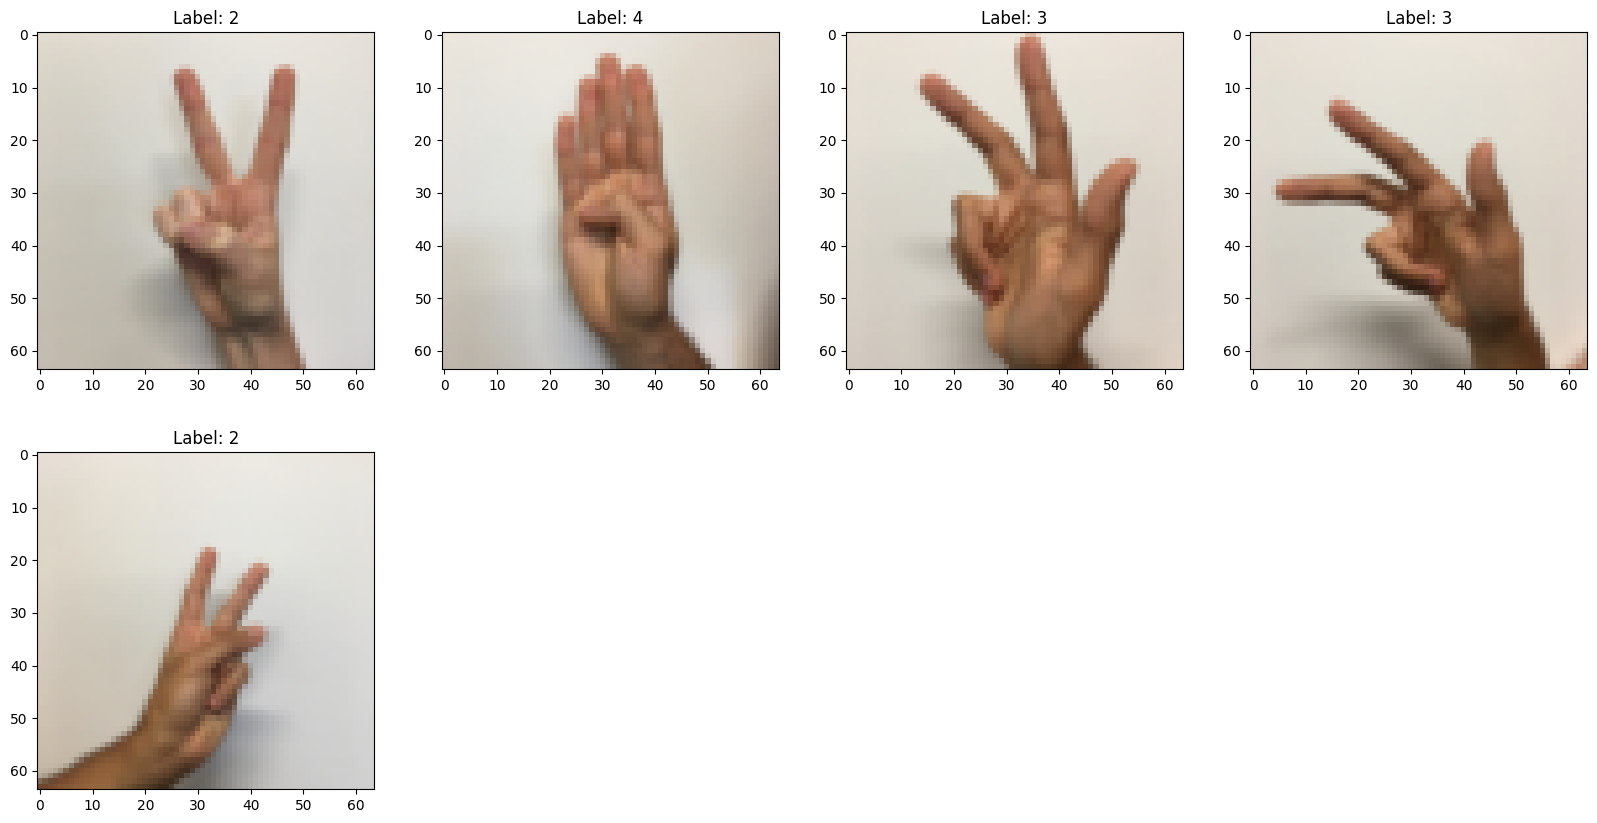

In [27]:
import random

indices = [random.randint(0, X_train.shape[0]) for _ in range(5)]
images = [X_train[index] for index in indices]
labels = [y_train[index] for index in indices]

display_images(images, labels)

In [28]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Build CNN Model

In [43]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Input image size: 64 * 64 * 3 (3 channels)

        # Layer Set 1: Convolutional Layer -> ReLU Layer -> Pooling Layer
        self.conv_layer_1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2)
        self.bn_1 = nn.BatchNorm2d(32)
        self.relu_1 = nn.ReLU()

        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Layer Set 2: Conv Layer -> ReLU Layer -> Max Pool Layer
        self.conv_layer_2 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn_2 = nn.BatchNorm2d(64)
        self.relu_2 = nn.ReLU()

        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected layers: Input (509 neurons) -> FC 1 (256 neurons) with ReLU -> FC 2 (128 neurons) with ReLU -> FC 3/Output (6 classes)
        self.fc_1 = nn.Linear(in_features=16*16*64, out_features=256)
        self.fc_1_relu = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.2)

        self.fc_2 = nn.Linear(in_features=256, out_features=128)
        self.fc_2_relu = nn.ReLU()
        self.dropout_2 = nn.Dropout(0.2)

        self.fc_3 = nn.Linear(in_features=128, out_features=6)

    def forward(self, X):
        # Conv Layer 1
        
        # print('0', X.shape)
        out = self.conv_layer_1(X)
        out = self.bn_1(out)
        out = self.relu_1(out)
        # print('1', out.shape)

        out = self.max_pool_1(out)
        # print('1,5', out.shape)

        # Conv Layer 2
        out = self.conv_layer_2(out)
        out = self.bn_2(out)
        out = self.relu_2(out)
        # print('2', out.shape)

        out = self.max_pool_2(out)
        # print('3', out.shape)

        # Flatten
        out = out.reshape(out.size(0), -1)
        # print('4', out.shape)

        # FC Layers
        out = self.fc_1(out)
        out = self.fc_1_relu(out)
        out = self.dropout_1(out)
        # print('5', out.shape)

        out = self.fc_2(out)
        out = self.fc_2_relu(out)
        out = self.dropout_2(out)
        # print('6', out.shape)

        out = self.fc_3(out)
        # print('7', out.shape)

        return out

# Set Hyperparameters

In [44]:
batch_size = 32
total_epochs = 10
learning_rate = .001

In [45]:
cnn_model = CNNModel().to(device)

In [46]:
error = nn.CrossEntropyLoss()

# SGD Optimizer
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=learning_rate)

In [47]:
train_dataset = CustomDataset(X_train, y_train)

train_data = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [48]:
cnn_model

CNNModel(
  (conv_layer_1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn_1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu_1): ReLU()
  (max_pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer_2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu_2): ReLU()
  (max_pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc_1): Linear(in_features=16384, out_features=256, bias=True)
  (fc_1_relu): ReLU()
  (dropout_1): Dropout(p=0.2, inplace=False)
  (fc_2): Linear(in_features=256, out_features=128, bias=True)
  (fc_2_relu): ReLU()
  (dropout_2): Dropout(p=0.2, inplace=False)
  (fc_3): Linear(in_features=128, out_features=6, bias=True)
)

In [49]:
num_of_iterations = X_train.shape[0] // batch_size

count = 0
loss_list = []
iteration_list = []

training_start_time = time.time()

for epoch in range(total_epochs):
    for i, (images, labels) in enumerate(train_data):
        images = images.float()
        images = images.permute(0, 3, 1, 2)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        output = cnn_model.forward(images)

        # Calculate loss
        loss = error(output, labels)

        # Backpropagation and calculate gradients
        loss.backward()

        # Update parameters
        optimizer.step()

        count += 1
        loss_list.append(loss)
        iteration_list.append(count)

        if i % 4 == 0:
            print(f"Epoch: [{epoch + 1}/{total_epochs}], step: [{i + 1}/{num_of_iterations}], loss: {loss.data:.4f}")
        
    

training_end_time = time.time()

print(f"\nTotal training time: {training_end_time - training_start_time} seconds")

Epoch: [1/10], step: [1/33], loss: 1.8025
Epoch: [1/10], step: [5/33], loss: 1.7731
Epoch: [1/10], step: [9/33], loss: 1.7684
Epoch: [1/10], step: [13/33], loss: 1.7655
Epoch: [1/10], step: [17/33], loss: 1.7799
Epoch: [1/10], step: [21/33], loss: 1.7984
Epoch: [1/10], step: [25/33], loss: 1.7882
Epoch: [1/10], step: [29/33], loss: 1.7754
Epoch: [1/10], step: [33/33], loss: 1.7499
Epoch: [2/10], step: [1/33], loss: 1.7576
Epoch: [2/10], step: [5/33], loss: 1.7551
Epoch: [2/10], step: [9/33], loss: 1.7752
Epoch: [2/10], step: [13/33], loss: 1.7879
Epoch: [2/10], step: [17/33], loss: 1.7702
Epoch: [2/10], step: [21/33], loss: 1.7341
Epoch: [2/10], step: [25/33], loss: 1.7357
Epoch: [2/10], step: [29/33], loss: 1.7644
Epoch: [2/10], step: [33/33], loss: 1.7197
Epoch: [3/10], step: [1/33], loss: 1.7492
Epoch: [3/10], step: [5/33], loss: 1.7563
Epoch: [3/10], step: [9/33], loss: 1.7420
Epoch: [3/10], step: [13/33], loss: 1.7083
Epoch: [3/10], step: [17/33], loss: 1.7292
Epoch: [3/10], step:

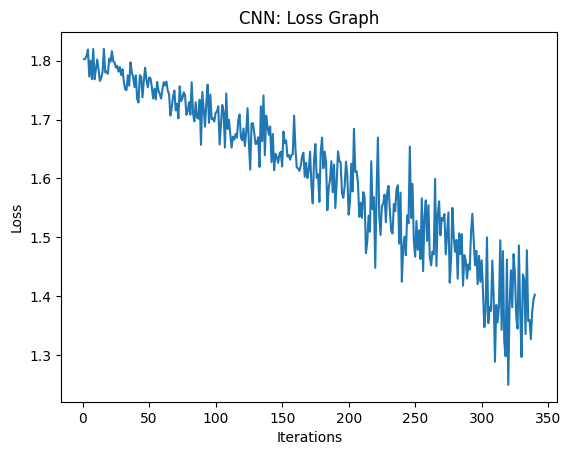

In [50]:
# Loss Graph

loss_list_numpy = [loss.detach().cpu().numpy() for loss in loss_list]

plt.plot(iteration_list, loss_list_numpy)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("CNN: Loss Graph")

plt.show()

# Model Evaluation

In [51]:
test_dataset = CustomDataset(X_test, y_test)

test_data = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [54]:
with torch.no_grad():
    total_test = 0
    total_correct = 0

    for i, (images, labels) in enumerate(test_data):
        images = images.float()
        images = images.permute(0, 3, 1, 2)

        output = cnn_model.forward(images)

        _, predictions = torch.max(output, 1)
        print(predictions.shape, labels.shape)
        print(predictions, labels)

        total_correct += (predictions == labels).sum().item()
        total_test += labels.shape[0]
        break

print(f"Total correct predictions: {total_correct}")
print(f"Total samples: {total_test}")
print(f"Accuracy: {total_correct / total_test * 100:.3f}%")

torch.Size([32]) torch.Size([32])
tensor([0, 0, 0, 5, 1, 0, 5, 1, 4, 1, 5, 1, 5, 1, 4, 4, 4, 5, 0, 4, 4, 4, 2, 4,
        5, 4, 0, 2, 2, 4, 5, 1]) tensor([0, 0, 0, 5, 1, 0, 3, 1, 5, 1, 5, 1, 3, 1, 1, 3, 5, 4, 0, 4, 5, 4, 2, 5,
        3, 5, 4, 2, 1, 2, 3, 1])
Total correct predictions: 17
Total samples: 32
Accuracy: 53.125%
